# WhatsApp Chat Analytics Dashboard

This notebook demonstrates a professional analytics dashboard built using:

- Python
- Pandas
- Matplotlib

The dashboard analyzes messaging activity and visualizes:

• Messages per user  
• Weekly activity  
• Sentiment analysis  
• Hourly chat activity  
• Daily chat timeline  
• Most used words

Cell 2: Import Required Libraries

In [1]:
import pandas as pd   
import numpy as np         
import matplotlib.pyplot as plt   # Data visualization

from matplotlib.gridspec import GridSpec  # Advanced dashboard layout system

from datetime import datetime, timedelta   # Generate random timestamps

import random

from collections import Counter    #Word frequency analysis

Cell 3: Generate Chat Dataset

In [2]:
# Generate a Sample WhatsApp Chat Dataset
# For this dashboard we generate synthetic chat data.

# ----------------- Define Chat Participants -----------------------

       # List of users participating in the group or individual chat
users = [          
"James",
"Michael",
"Daniel",
"Emma",
"Olivia"
]

# ----------------- Message distribution per user -----------------------

    # Defining custom weights to make the data look realistic (some users are more active than others)
user_ratio = {
"James":187,
"Michael":155,
"Daniel":169,
"Emma":122,
"Olivia":44
}

# ----------------- # Example Messages Used in Chat -----------------------

        # A pool of common phrases to randomly assign to chat records
messages = [
"How are you?",
"Hello Waqas Shakir",
"Good idea Waqas",
"See you tomorrow",
"Hahaha",
"Ok"
]

start = datetime(2024,1,1)    # Start Date for Chat History
data = []                     # Initialize data list

for user,count in user_ratio.items():      # Generate Random Chat Records

    for i in range(count):

             # Generate a random timestamp within a 60-day window from the start date
        dt = start + timedelta(
            days=random.randint(0,60),
            hours=random.randint(0,23),
            minutes=random.randint(0,59)
        )

        msg = random.choice(messages)     # Pick a random message from our predefined list

        data.append([dt,user,msg])     # Append the record as a list:

df = pd.DataFrame(           # Structuring the raw list into a table format for easier analysis
data,
columns=["DateTime","User","Message"]
)

# ----------------- Extract Time Features for Analysis -----------------------

df["Hour"] = df["DateTime"].dt.hour        # Hour of message

df["Day"] = df["DateTime"].dt.day_name()   # Day name (Monday, Tuesday etc)

df["Date"] = df["DateTime"].dt.date        # Date only (for timeline)

df.head()


,DateTime,User,Message,Hour,Day,Date
0,2024-01-24 19:35:00,James,See you tomorrow,19,Wednesday,2024-01-24
1,2024-01-09 17:16:00,James,Good idea Waqas,17,Tuesday,2024-01-09
2,2024-01-26 16:26:00,James,Hahaha,16,Friday,2024-01-26
3,2024-01-19 02:55:00,James,Ok,2,Friday,2024-01-19
4,2024-01-06 04:58:00,James,Good idea Waqas,4,Saturday,2024-01-06


Cell 4: Build Complete Dashboard

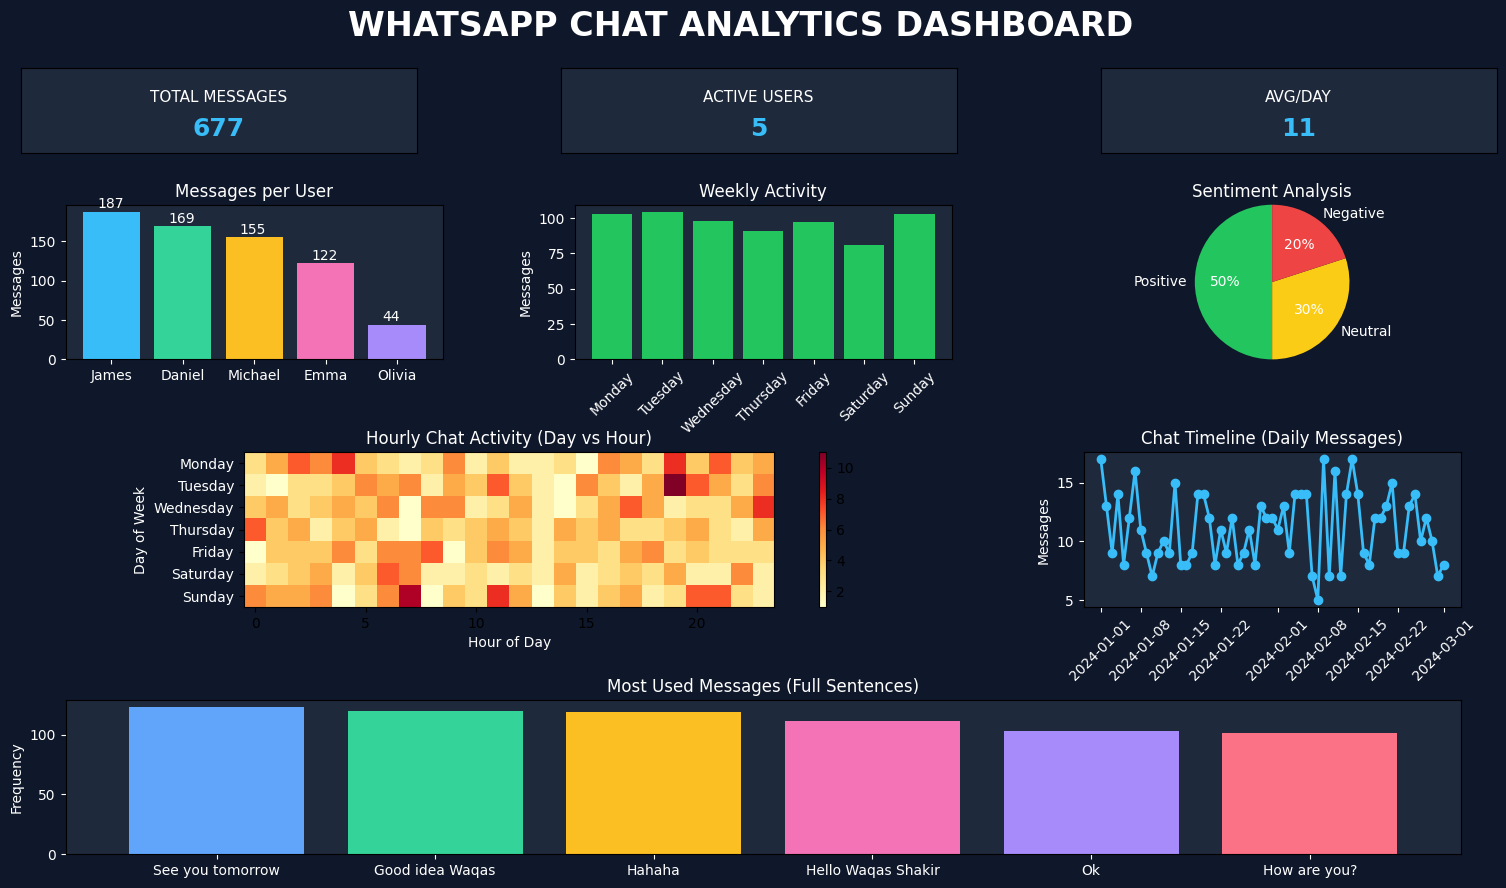

In [3]:
# ----------------- Dashboard Theme Colors -----------------------

BG = "#0f172a"       # overall background
CARD = "#1e293b"    # chart background
TEXT = "white"      # text color
PRIMARY = "#38bdf8" # accent color
ACCENT = "#22c55e"

fig = plt.figure(figsize=(18,13))   # Create Main Dashboard Figure

fig.patch.set_facecolor(BG)     # Set the outer background color

gs = GridSpec(4,3,figure=fig)  # Define a 4x3 Grid Layout to organize different charts

# ----------------- KPI SUMMARY CARDS -----------------------

kpis = [
("TOTAL MESSAGES",len(df)),
("ACTIVE USERS",df["User"].nunique()),
("AVG/DAY",round(len(df)/60))
]

for i,(label,val) in enumerate(kpis):

    ax = fig.add_axes([0.1+i*0.3,0.84,0.22,0.065])  # Creating custom axes for Cards outside the standard grid
    ax.set_facecolor(CARD)

        # Centering the Metric Label and the Dynamic Value
    ax.text(0.5,0.6,label,     
            ha='center',
            color=TEXT,
            fontsize=11)

    ax.text(0.5,0.2,str(val),
            ha='center',
            color=PRIMARY,
            fontsize=18,
            fontweight="bold")

    ax.set_xticks([])       # Removing axis ticks
    ax.set_yticks([])


# ----------------- # Messages per User (Bar Chart) -----------------------
 
       # Visualizes the contribution of each user in the chat
ax1 = fig.add_subplot(gs[0,0])
ax1.set_facecolor(CARD)

user_counts = df["User"].value_counts()

bars = ax1.bar(
user_counts.index,
user_counts.values,
color=["#38bdf8","#34d399","#fbbf24","#f472b6","#a78bfa"]
)

ax1.set_title("Messages per User",color=TEXT)
ax1.set_ylabel("Messages",color=TEXT)

ax1.tick_params(colors=TEXT)

for bar in bars:               # Show numbers above bars
    ax1.text(bar.get_x()+0.2,
             bar.get_height()+5,
             int(bar.get_height()),
             color=TEXT)

# ----------------- # Weekly Activity Chart -----------------------
       # Shows which days of the week are most active
ax2 = fig.add_subplot(gs[0,1])
ax2.set_facecolor(CARD)

order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

weekly = df["Day"].value_counts().reindex(order)

ax2.bar(weekly.index,weekly.values,color=ACCENT)

ax2.set_title("Weekly Activity",color=TEXT)
ax2.set_ylabel("Messages",color=TEXT)

ax2.tick_params(axis="x",rotation=45,colors=TEXT)     # Rotate labels for better fit
ax2.tick_params(axis="y",colors=TEXT)

# ----------------- Sentiment Analysis Pie Chart -----------------------

     # Distribution of the overall "Mood" of the conversation
ax3 = fig.add_subplot(gs[0,2])     
ax3.set_facecolor(CARD)

sentiment = [50,30,20]       # Placeholder data (Positive, Neutral, Negative)

labels=["Positive","Neutral","Negative"]

ax3.pie(
sentiment,
labels=labels,
autopct="%1.0f%%",          # Display percentages inside slices           
colors=["#22c55e","#facc15","#ef4444"],
startangle=90,
textprops={"color":"white"},
radius=1.25
)

ax3.set_title("Sentiment Analysis",color=TEXT)

# ----------------- Hourly Chat Activity Heatmap -----------------------

ax4 = fig.add_subplot(gs[1,0:2])       # Matrix view showing the intersection of Day and Time (Peak hours)
ax4.set_facecolor(CARD)
                         # Creating a frequency matrix (Pivot Table) of Day vs Hour
heat = pd.crosstab(df["Day"],df["Hour"]).reindex(order)
 
im=ax4.imshow(heat,cmap="YlOrRd")      # Color intensity represents message volume

ax4.set_title("Hourly Chat Activity (Day vs Hour)",color=TEXT)
ax4.set_xlabel("Hour of Day",color=TEXT)
ax4.set_ylabel("Day of Week",color=TEXT)

ax4.set_yticks(range(len(order)))
ax4.set_yticklabels(order,color=TEXT)

plt.colorbar(im,ax=ax4)       # Add color scale legend

# ----------------- Chat Timeline (Daily Messages) -----------------------
            
ax5 = fig.add_subplot(gs[1,2])      # A line graph tracking message volume over time
ax5.set_facecolor(CARD)

timeline = df.groupby("Date").size()

ax5.plot(
timeline.index,
timeline.values,
marker="o",
linewidth=2,
color=PRIMARY
)

ax5.set_title("Chat Timeline (Daily Messages)",color=TEXT)
ax5.set_ylabel("Messages",color=TEXT)

ax5.tick_params(axis="x",rotation=45,colors=TEXT)
ax5.tick_params(axis="y",colors=TEXT)     

# ----------------- Most Used Words Chart -----------------------

# ----------------- Most Used Messages Chart -----------------------
# Instead of word frequency, we are counting full message occurrences 
# to see the most common phrases used in the chat.

ax6 = fig.add_subplot(gs[2,:])          
ax6.set_facecolor(CARD)

# We avoid using .split() here so that the entire sentence remains intact 
# (e.g., "Hello Waqas" is counted as one unit rather than "Hello" and "Waqas").
top_messages = df["Message"].value_counts().head(10)

labels = top_messages.index
values = top_messages.values

# Assigning a distinct color palette for the top 10 most used messages
colors = [
    "#60a5fa", "#34d399", "#fbbf24", "#f472b6", "#a78bfa",
    "#fb7185", "#22c55e", "#38bdf8", "#f59e0b", "#818cf8"
]

ax6.bar(labels, values, color=colors)

# Updating the title to reflect that we are now analyzing full sentences
ax6.set_title("Most Used Messages (Full Sentences)", color=TEXT)
ax6.set_ylabel("Frequency", color=TEXT)
ax6.tick_params(colors=TEXT)


# ----------------- Dashboard Title + Layout Fix -----------------------

fig.suptitle(                                 # Adding a high-level title for the entire dashboard
"WHATSAPP CHAT ANALYTICS DASHBOARD",
fontsize=24,
fontweight="bold",
color="white",
y=0.95
)
     # Optimize spacing between subplots to prevent overlapping  
plt.subplots_adjust(top=0.80, hspace=0.6, wspace=0.35)

plt.savefig("whatsapp_dashboard.png", dpi=300,     # Save the dashboard as a high-resolution image
bbox_inches='tight',
facecolor=fig.get_facecolor()
)

plt.show()